In [168]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

import numpy untuk mengolah data atau nilai piksel yg berbentuk array atau matriks.

import cv2 digunakan untuk mengimport library OpenCV. penggunaan library dalam kode ini digunakan untuk mengubah warna menjadi abu atau grayscale.

import matplotlib.pyplot as plt digunakan untuk memanggil modul pyplot dari library Matplotlib dengan alias plt. Modul ini berfungsi untuk menampilkan visualisasi, seperti gambar dan grafik.

In [128]:
img1 = cv2.imread('Assets/Bunga.png')
img2 = cv2.imread('Assets/Langit.png')
img3 = cv2.imread('Assets/Meledak.png')
img4 = cv2.imread('Assets/Windut.png')

# supaya warnanya keluar
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

kode cv2.imread digunakan untuk membaca citra bunga, langit, meledak, dan windut dari folder Assets. Setelah citra berhasil dibaca, dilakukan peoses konversi warna dari format BGR ke RGB menggunakan cv2.cvtColor().

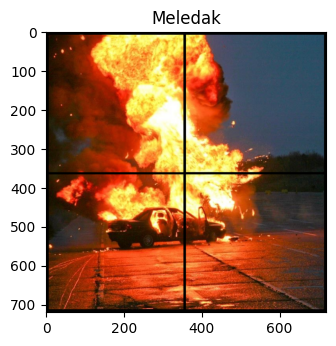

In [129]:
# menampilkan gambar
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img3)
plt.title("Meledak")

plt.show()

dalam proses ini menampilkan citra img3 yaitu gambar Meledak. fungsi plt.figure(figsize=(12,8)) untuk mengatur ukuran tampilan gambar agar lebih besar dan jelas. plt.subplot(2,2,1) menempatkan gambar pada posisi pertama dari susunan 2 baris dan 2 kolom. plt.show() digunakan untuk menampilkan hasil visualisasi citra ke layar.

Text(0.5, 1.0, 'Part 4')

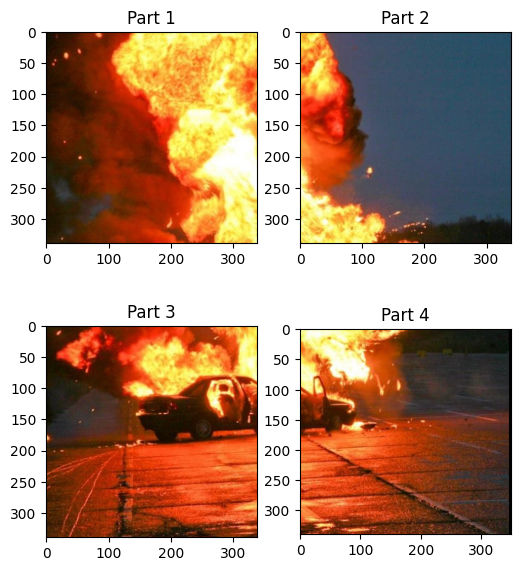

In [130]:
def slice(gambar, a, b, mode='H'): 
    return gambar[a:b, :] if mode == 'H' else gambar[:, a:b]

ctr1 = slice(img3, 10, 350, 'H')
ctr1 = slice(ctr1, 10, 350, 'V')

ctr2 = slice(img3, 10, 350, 'H')
ctr2 = slice(ctr2, 370, 710, 'V')

ctr3 = slice(img3, 370, 710, 'H')
ctr3 = slice(ctr3, 10, 350, 'V')

ctr4 = slice(img3, 370, 710, 'H')
ctr4 = slice(ctr4, 370, 720, 'V')

plt.figure(figsize=(6,7))

plt.subplot(2,2,1)
plt.imshow(ctr1, cmap="gray")
plt.title("Part 1")
plt.subplot(2,2,2)
plt.imshow(ctr2, cmap="gray")

plt.title("Part 2")
plt.subplot(2,2,3)
plt.imshow(ctr3, cmap="gray")
plt.title("Part 3")
plt.subplot(2,2,4)
plt.imshow(ctr4, cmap="gray")
plt.title("Part 4")


fungsi di atas merupakan fungsi slicing atau pemisahan citra. citra dibagi menjadi 4 bagian dengan ukuran tertentu agar potongan setiap citra pas.

In [131]:
def ukuran_min(gambar):
    baris_min = min(len(citra) for citra in gambar)
    kolom_min = min(len(citra[0]) for citra in gambar)
    return baris_min, kolom_min

def potong(citra, tinggi, lebar):
    return [row[:lebar] for row in citra[:tinggi]]

def resize_semua(gambar):
    tinggi_min, lebar_min = ukuran_min(gambar)
    return [potong(citra, tinggi_min, lebar_min) for citra in gambar]

def ukuran_max(gambar):
    baris_max = max(len(citra) for citra in gambar)
    kolom_max = max(len(row) for citra in gambar for row in citra)
    return baris_max, kolom_max

def normalisasi(citra, baris_tujuan, kolom_tujuan):
    hasil = []
    for i in range(baris_tujuan):
        baris = []
        for j in range(kolom_tujuan):
            if i < len(citra) and j < len(citra[i]):
                baris.append(citra[i][j])
            else:
                baris.append(0)
        hasil.append(baris)
    return hasil

def gabung_2x2(citra1, citra2, citra3, citra4):
    citra1, citra2, citra3, citra4 = resize_semua([citra1, citra2, citra3, citra4])

    b, k = ukuran_max([citra1, citra2, citra3, citra4])
    i1 = normalisasi(citra1, b, k)
    i2 = normalisasi(citra2, b, k)
    i3 = normalisasi(citra3, b, k)
    i4 = normalisasi(citra4, b, k)

    gabung = []
    for i in range(b * 2):
        baris = []
        for j in range(k * 2):
            if i < b and j < k:
                baris.append(i1[i][j]) 
            elif i < b and j >= k:
                baris.append(i2[i][j - k]) 
            elif i >= b and j < k:
                baris.append(i3[i - b][j])
            else:
                baris.append(i4[i - b][j - k]) 
        gabung.append(baris)

    return gabung



Kode di atas digunakan untuk menyamakan ukuran beberapa citra dan menggabungkannya menjadi susunan 2×2. Fungsi ukuran_min() mencari ukuran terkecil dari seluruh citra agar proses pemotongan dapat dilakukan secara seragam, sedangkan potong() dan resize_semua() digunakan untuk memotong citra sesuai ukuran minimum tersebut. Setelah itu, ukuran_max() dan normalisasi() digunakan untuk menyesuaikan ukuran citra dengan menambahkan nilai 0 jika diperlukan. Pada tahap akhir, fungsi gabung_2x2() menggabungkan empat citra menjadi satu tampilan dalam bentuk grid 2×2 menggunakan perulangan.

Text(0.5, 1.0, 'Gabungan Meledak')

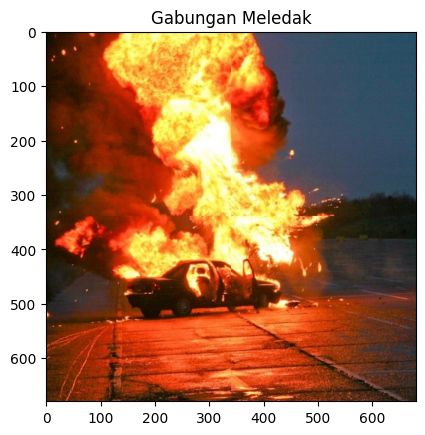

In [169]:
merge_meledak = gabung_2x2(ctr1, ctr2, ctr3, ctr4)

plt.imshow(merge_meledak)
plt.title("Gabungan Meledak")

kode di atas menampilkan citra yang telah digabungkan atau dimerge dengan memanggil fungsi gabung_2x2 dan disimpan didalam merge_baru. lalu merge_baru dipanggil dengan plt.imshow().

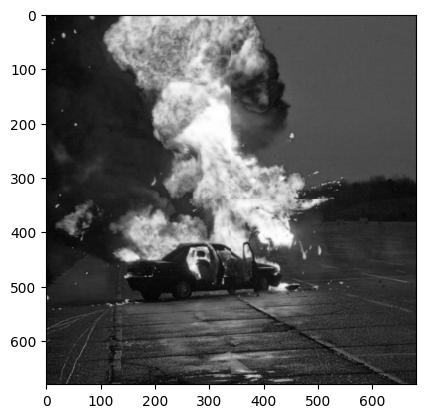

In [133]:
gray_merge = cv2.cvtColor(np.array(merge_meledak), cv2.COLOR_BGR2GRAY)

plt.imshow(gray_merge, cmap="gray")
plt.show()

kode di atas menampilkan hasil gabungan tadi diubah ke grayscale. setelah itu fungsi dipanggil setelah disimpan ke gray_merge dan cmap='gray' agar grayscale terbaca.

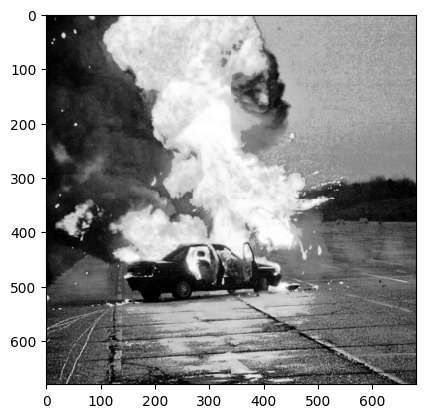

In [134]:
def ekualisasi(citra):
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)

    # Hitung histogram citra
    for i in range(height):
        for j in range(width):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    # Hitung CDF dari index 1 sampai 255
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # Normalisasi CDF ke rentang [0, 255]
    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)

    hasil = np.zeros_like(citra, dtype=np.uint8)

    # Terapkan CDF yang sudah dinormalisasi ke setiap pixel
    for i in range(height):
        for j in range(width):
            hasil[i, j] = cdf_normal[citra[i, j]]

    return hasil

# Cara memanggil:
# hasil_ekualisasi = ekualisasi(citra_kalian)

hasil_ekualisasi = ekualisasi(gray_merge)
plt.imshow(hasil_ekualisasi, cmap="gray")

Kode tersebut digunakan untuk melakukan histogram equalization pada citra grayscale guna meningkatkan kontras gambar. Proses dimulai dengan menghitung histogram intensitas piksel, kemudian dibuat nilai CDF (Cumulative Distribution Function) untuk menyebarkan distribusi intensitas secara lebih merata. Setelah dinormalisasi ke rentang 0–255, nilai CDF diterapkan kembali ke setiap piksel sehingga detail citra menjadi lebih jelas. Hasil akhirnya ditampilkan menggunakan plt.imshow() dengan mode grayscale.

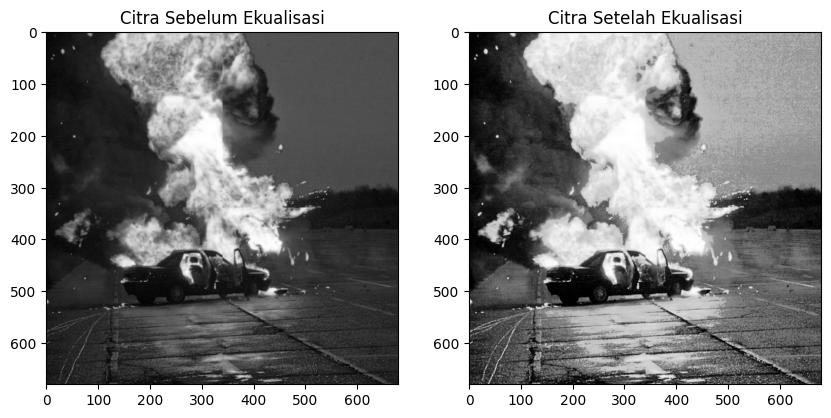

In [135]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(gray_merge, cmap="gray")
plt.title("Citra Sebelum Ekualisasi")
plt.subplot(1,2,2)
plt.imshow(hasil_ekualisasi, cmap="gray")
plt.title("Citra Setelah Ekualisasi")
plt.show()

gambar diatas merupakan sebuah perbandingan citra sebelum ekualisasi dan setelah ekualisasi. terlihat perbedaan bahwa citra setelah diekualisasi lebih cerah dibandingkan dengan citra sebelum diekualisasi. ini merupakan definisi dari ekualisasi histogram yaitu meningkatkan kontras gambar dengan menyebarkan distribusi intensitas piksel secara lebih merata.

In [136]:
# ====================================
# FUNGSI HISTOGRAM
# ====================================

def buat_histogram(citra):

    # histogram kosong
    hist = [0] * 256

    # ukuran gambar
    height, width = citra.shape

    # hitung jumlah pixel
    for i in range(height):
        for j in range(width):

            nilai_pixel = int(citra[i][j])

            hist[nilai_pixel] += 1

    return hist


# ====================================
# FUNGSI TAMPILKAN HISTOGRAM
# ====================================

def plot_histogram(histogram, title, warna):

    plt.bar(range(256), histogram, color=warna, width=1)

    plt.title(title)
    plt.xlabel("Intensitas Pixel")
    plt.ylabel("Jumlah Pixel")
    plt.xlim(0,255)
    plt.legend()

Kode di atas digunakan untuk membuat dan menampilkan histogram citra grayscale. Fungsi buat_histogram() menghitung jumlah kemunculan setiap nilai intensitas piksel dari 0–255 menggunakan perulangan, kemudian menyimpannya ke dalam array histogram. Selanjutnya, fungsi plot_histogram() digunakan untuk memvisualisasikan distribusi intensitas piksel dalam bentuk diagram batang sehingga penyebaran tingkat kecerahan pada citra dapat dianalisis dengan lebih mudah.

C:\Users\USER\AppData\Local\Temp\ipykernel_17264\1224594344.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


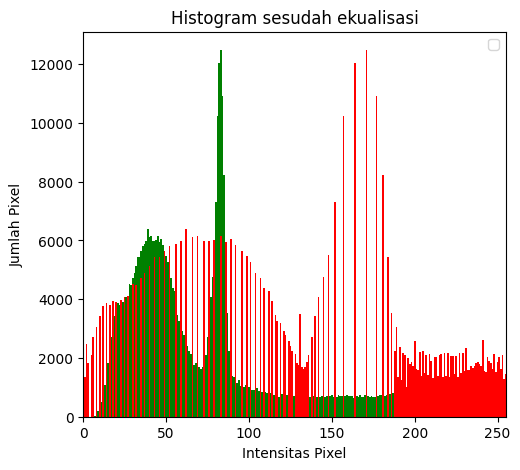

In [137]:
sebelum_eq = buat_histogram(gray_merge)
sesudah_eq = buat_histogram(hasil_ekualisasi)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_histogram(sebelum_eq, "Histogram sebelum ekualisasi", "green")
plot_histogram(sesudah_eq, "Histogram sesudah ekualisasi", "red")

Kode di atas digunakan untuk membandingkan histogram citra sebelum dan sesudah proses histogram equalization. Histogram dari citra grayscale asli disimpan pada variabel sebelum_eq, sedangkan histogram hasil ekualisasi disimpan pada sesudah_eq. Setelah itu, kedua histogram ditampilkan menggunakan fungsi plot_histogram() agar perubahan distribusi intensitas piksel dapat terlihat dengan jelas. Perbandingan ini menunjukkan bahwa proses ekualisasi membuat penyebaran intensitas menjadi lebih merata sehingga kontras citra meningkat.

(720, 720)
(400, 400)


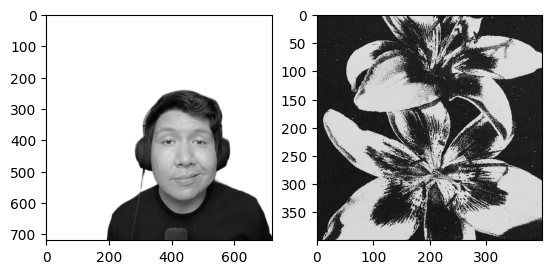

In [138]:
windut = cv2.imread("Assets/Windut.png")
bunga = cv2.imread("Assets/Bunga.png")

windut_gray = cv2.cvtColor(windut, cv2.COLOR_BGR2GRAY)
bunga_gray = cv2.cvtColor(bunga, cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(windut_gray, cmap="gray")
print(windut_gray.shape)
plt.subplot(1,2,2)
plt.imshow(bunga_gray, cmap="gray")
print(bunga_gray.shape)


Kode di atas digunakan untuk membaca citra Windut dan Bunga, kemudian mengubah keduanya menjadi citra grayscale menggunakan cv2.cvtColor(). Proses grayscale dilakukan agar pengolahan citra seperti histogram dan spesifikasi histogram dapat dilakukan dengan lebih mudah karena hanya menggunakan satu kanal intensitas. Selanjutnya, kedua citra ditampilkan menggunakan plt.imshow() dengan mode grayscale, dan ukuran dimensi masing-masing citra ditampilkan menggunakan print() untuk mengetahui tinggi dan lebar gambar sebelum proses berikutnya dilakukan.

In [139]:
def spesifikasi_histogram(citra_asal, citra_target):
    height, width = citra_asal.shape

    hist_asal = [0] * 256
    hist_target = [0] * 256

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):

            pixel = int(citra_asal[i][j])

            hist_asal[pixel] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):

            pixel = int(citra_target[i][j])

            hist_target[pixel] += 1

    cdf_asal = [0] * 256
    cdf_target = [0] * 256

    cdf_asal[0] = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):

        cdf_asal[i] = cdf_asal[i - 1] + hist_asal[i]

        cdf_target[i] = cdf_target[i - 1] + hist_target[i]

    cdf_asal = np.array(cdf_asal) / cdf_asal[-1]
    cdf_target = np.array(cdf_target) / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        selisih = np.abs(cdf_target - cdf_asal[i])
        map_hist[i] = np.argmin(selisih)

    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            pixel_lama = citra_asal[i][j]
            hasil[i][j] = map_hist[pixel_lama]

    return hasil

Kode di atas digunakan untuk melakukan spesifikasi histogram, yaitu proses menyesuaikan distribusi intensitas citra asal agar menyerupai citra target. Program dimulai dengan menghitung histogram dan CDF dari kedua citra, kemudian mencari pemetaan intensitas piksel berdasarkan selisih CDF terkecil. Setelah itu, setiap piksel pada citra asal diganti menggunakan hasil pemetaan tersebut sehingga karakteristik kontras dan pencahayaan citra asal menjadi mirip dengan citra target.

(720, 720)


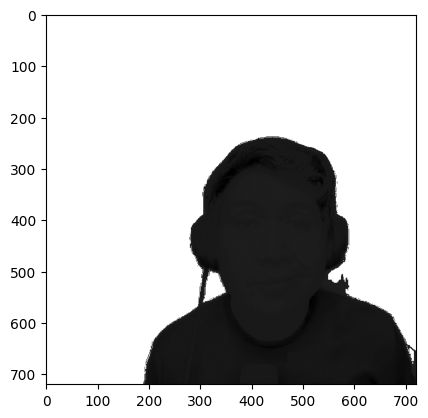

In [140]:
windut_sp = spesifikasi_histogram(windut_gray, bunga_gray)
plt.imshow(windut_sp, cmap="gray")
print(windut_sp.shape)

Kode di atas digunakan untuk menerapkan proses spesifikasi histogram pada citra Windut dengan citra Bunga sebagai referensi. Fungsi spesifikasi_histogram() menghasilkan citra baru bernama windut_sp yang memiliki distribusi intensitas menyerupai citra target sehingga kontras dan pencahayaannya menjadi lebih sesuai. Hasil citra kemudian ditampilkan menggunakan plt.imshow() dalam mode grayscale, sedangkan print(windut_sp.shape) digunakan untuk melihat ukuran dimensi citra hasil spesifikasi.

C:\Users\USER\AppData\Local\Temp\ipykernel_17264\1224594344.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


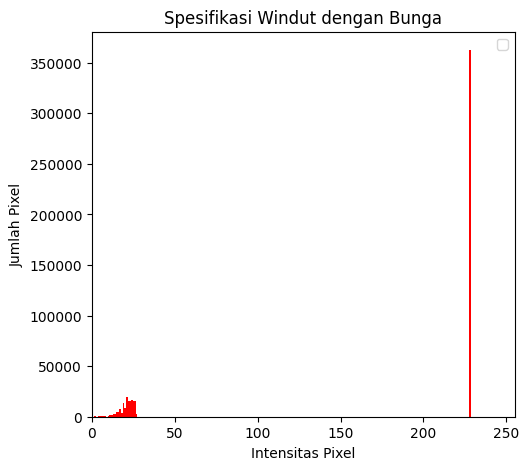

In [141]:
sebelum_eq = buat_histogram(windut_sp)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_histogram(sebelum_eq, "Spesifikasi Windut dengan Bunga", "red")

Kode di atas digunakan untuk menampilkan histogram hasil spesifikasi histogram pada citra Windut. Fungsi buat_histogram() menghitung distribusi intensitas piksel dari citra windut_sp, kemudian hasilnya divisualisasikan menggunakan plot_histogram() dalam bentuk diagram batang berwarna merah. Histogram ini digunakan untuk melihat perubahan penyebaran intensitas setelah proses spesifikasi sehingga dapat dianalisis apakah karakteristik citra sudah menyerupai citra referensi.

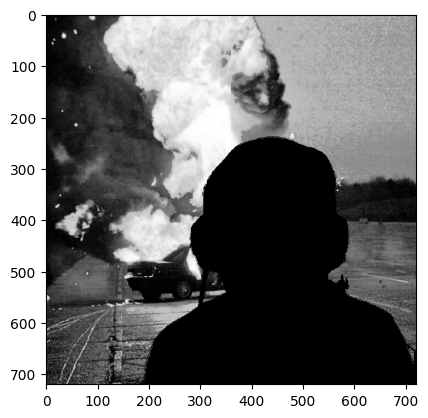

In [142]:
def copy_citra(citra):
    h, w = citra.shape
    hasil = np.zeros((h,w), dtype=citra.dtype)

    for i in range(h):
        for j in range(w):
            hasil[i][j]=citra[i][j]
    return hasil

def tumpuk(citra_depan, citra_belakang):
    hasil = copy_citra(citra_depan)
    
    for i in range(citra_depan.shape[0]):
        for j in range(citra_depan.shape[1]):
            if citra_depan[i,j]>50:
                hasil[i,j] = citra_belakang[i,j]
            else:
                hasil[i,j] = 0
    return hasil

def resize(citra, tinggi_baru, lebar_baru):
    tinggi_asal, lebar_asal = citra.shape[:2]
    skala_y = tinggi_asal / tinggi_baru
    skala_x = lebar_asal / lebar_baru

    if len(citra.shape) == 3:
        hasil = np.zeros((tinggi_baru, lebar_baru, citra.shape[2]), dtype=np.uint8)
    else:
        hasil = np.zeros((tinggi_baru, lebar_baru), dtype=np.uint8)
    
    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            y_asal = min(int(i * skala_y), tinggi_asal - 1)
            x_asal = min(int(j * skala_x), lebar_asal - 1)
            hasil[i,j] = citra[y_asal, x_asal]
    return hasil

meledak_ek = resize(hasil_ekualisasi, 720, 720)
windah_mel = tumpuk(windut_sp, meledak_ek)
plt.imshow(windah_mel, cmap="gray")

Kode di atas digunakan untuk menyalin citra, mengubah ukuran citra, dan melakukan proses masking atau penumpukan gambar. Fungsi resize() digunakan untuk menyamakan ukuran citra menggunakan perulangan tanpa fungsi bawaan resize, sedangkan fungsi tumpuk() digunakan untuk mengambil bagian tertentu dari citra belakang berdasarkan nilai intensitas piksel pada citra depan. Jika nilai piksel lebih dari 50 maka piksel dari citra belakang akan digunakan, sehingga menghasilkan efek penggabungan antara citra Windut hasil spesifikasi dengan citra hasil ekualisasi Meledak.

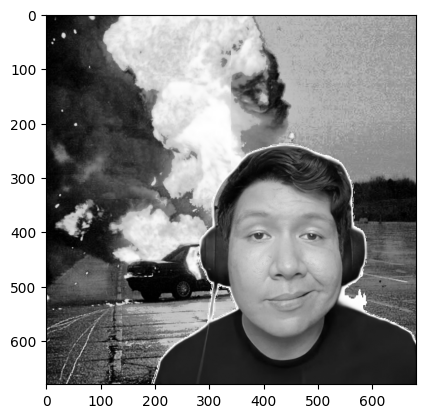

In [143]:
def tumpuk_depan(citra_hitam, citra_asli, citra_belakang):
    
    tinggi = min(citra_hitam.shape[0], citra_asli.shape[0], citra_belakang.shape[0])
    lebar = min(citra_hitam.shape[1], citra_asli.shape[1], citra_belakang.shape[1])

    hasil = copy_citra(citra_belakang)

    for i in range(tinggi):
        for j in range(lebar):
            if citra_hitam[i, j] < 50:
                hasil[i, j] = citra_asli[i, j]
    return hasil

windut_melet = tumpuk_depan(windut_sp, windut_gray, hasil_ekualisasi)
plt.imshow(windut_melet, cmap="gray")
plt.show()

Kode di atas digunakan untuk menggabungkan objek utama dengan citra latar belakang menggunakan teknik masking. Fungsi tumpuk_depan() membandingkan nilai intensitas pada citra_hitam, kemudian jika nilai piksel kurang dari 50 maka bagian tersebut akan diisi menggunakan piksel dari citra_asli, sedangkan area lainnya tetap menggunakan citra belakang. Proses ini menghasilkan penggabungan objek Windut dengan background hasil ekualisasi sehingga objek utama terlihat menyatu dengan latar belakang.

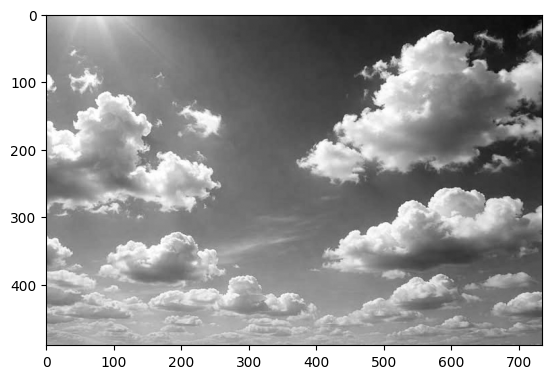

In [153]:
langit = cv2.imread('Assets/Langit.png')
langit_gray = cv2.cvtColor(langit, cv2.COLOR_RGB2GRAY)
plt.imshow(langit_gray, cmap="gray")

Kode di atas digunakan untuk membaca citra Langit dan mengubahnya menjadi citra grayscale menggunakan cv2.cvtColor(). Proses grayscale dilakukan agar citra hanya memiliki satu kanal intensitas sehingga lebih mudah digunakan pada proses pengolahan citra selanjutnya, seperti histogram atau spesifikasi histogram. Hasil citra grayscale kemudian ditampilkan menggunakan plt.imshow() dengan mode grayscale.

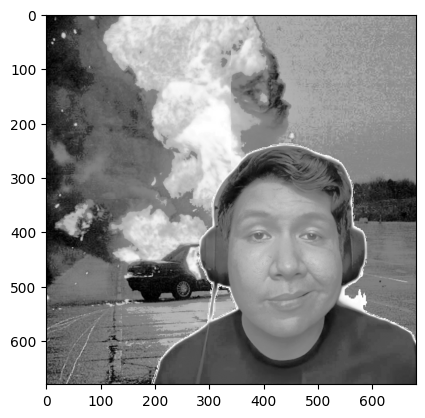

In [154]:
spe_winlang = spesifikasi_histogram(windut_melet, langit_gray)
plt.imshow(spe_winlang, cmap="gray")

Kode di atas digunakan untuk melakukan spesifikasi histogram pada citra windut_melet dengan citra langit_gray sebagai referensi. Proses ini bertujuan menyesuaikan distribusi intensitas piksel agar pencahayaan dan kontras citra hasil penggabungan menjadi lebih menyerupai citra langit sehingga tampilan akhir terlihat lebih menyatu. Hasil spesifikasi kemudian ditampilkan menggunakan plt.imshow() dalam mode grayscale.

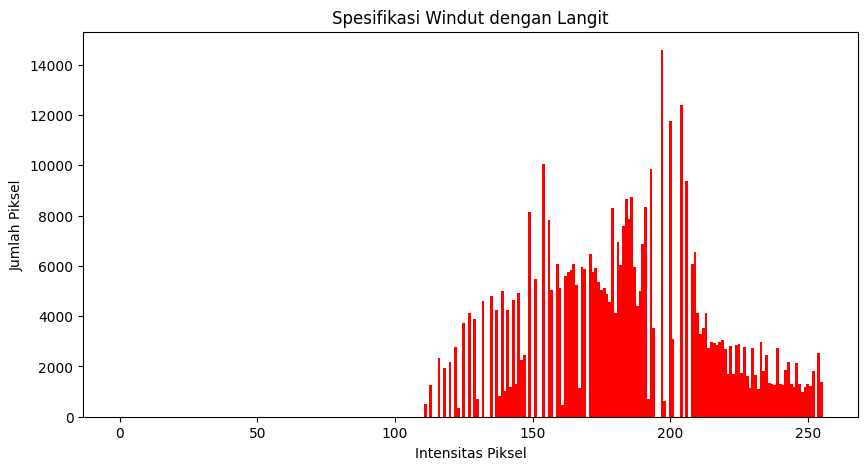

In [157]:
def tampilkan_histogram(citra, warna='black'):
    histogram = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            nilai = citra[i, j]
            histogram[nilai] += 1
    plt.figure(figsize=(10, 5))
    plt.bar(range(256), histogram, width=1, color=warna)
    plt.title('Spesifikasi Windut dengan Langit')
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Jumlah Piksel')
    plt.show()
    return histogram
tampilkan_histogram(spe_winlang, 'red')
plt.show()

Kode di atas digunakan untuk menghitung dan menampilkan histogram dari citra spe_winlang. Program menghitung jumlah kemunculan setiap intensitas piksel dari 0–255 menggunakan perulangan, kemudian menampilkannya dalam bentuk diagram batang berwarna merah menggunakan plt.bar(). Histogram ini digunakan untuk melihat distribusi intensitas piksel setelah proses spesifikasi histogram sehingga perubahan kontras dan pencahayaan citra dapat dianalisis dengan lebih jelas.

In [172]:
windutcerah = cv2.imread('Assets/Windut.png')           

meledakcerah = cv2.cvtColor(np.array(merge_meledak, dtype=np.uint8), cv2.COLOR_BGR2RGB)
windutcerah = resize(windutcerah, 720, 720)
meledakcerah = resize(meledakcerah, 720, 720)

Kode di atas digunakan untuk membaca citra Windut dan menyiapkan citra hasil gabungan "Meledak" agar memiliki format dan ukuran yang sama. Citra merge_meledak terlebih dahulu diubah menjadi array bertipe uint8 lalu dikonversi ke format RGB menggunakan cv2.cvtColor() agar warna tampil dengan benar. Setelah itu, kedua citra diubah ukurannya menjadi 720×720 menggunakan fungsi resize() sehingga dapat diproses atau digabungkan dengan ukuran yang seragam.

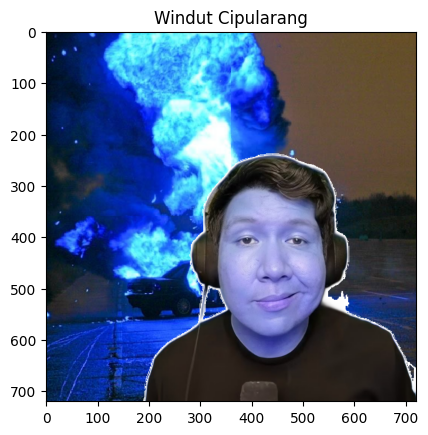

In [174]:
def tumpuk_depan_color(citra_hitam, citra_asli_color, citra_belakang_color):
    hasil = np.zeros((citra_belakang_color.shape[0], citra_belakang_color.shape[1], 3), dtype=np.uint8)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   
                hasil[i, j] = citra_asli_color[i, j]
            else:                         
                hasil[i, j] = citra_belakang_color[i, j]

    return hasil

windah_mel_color = tumpuk_depan_color(windut_sp, windutcerah, meledakcerah)

plt.imshow(windah_mel_color)   
plt.title("Windut Cipularang")
plt.show()

Kode di atas digunakan untuk menggabungkan citra berwarna menggunakan teknik masking. Fungsi tumpuk_depan_color() memeriksa nilai intensitas pada citra_hitam, kemudian jika nilai piksel kurang dari 50 maka piksel dari citra asli berwarna akan digunakan, sedangkan area lainnya diisi dengan citra background berwarna. Proses ini menghasilkan citra gabungan berwarna antara Windut dan background Meledak sehingga objek utama terlihat lebih menyatu dan menarik secara visual.